# GAM: theory, fitting, inference, and constrained effects

This notebook develops one coherent energy-system case study while introducing
NAMpy's strict `mgcv`-aligned GAM backend. We model continuous demand, event
counts, binary alerts, positive costs, and distributional location/scale using
the same covariates. Every example is executed during notebook generation, so
the checked-in artifact includes fitted results and visual diagnostics.


## 1. Additive predictors and exponential-family responses

For an exponential-family response, the conditional mean $\mu_i$ is connected
to an additive predictor through a link $g$:

$$
g(\mu_i)=\eta_i=\beta_0+\sum_j f_j(x_{ij})
+\sum_r z_{ir}\beta_r+o_i.
$$

The offset $o_i$ has a fixed coefficient of one. Each smooth is represented in
a finite basis,

$$
f_j(x)=\sum_{k=1}^{K_j}B_{jk}(x)\beta_{jk}
=\mathbf B_j(x)^\top\boldsymbol\beta_j,
$$

so fitting is finite-dimensional. A roughness penalty
$\lambda_j\boldsymbol\beta_j^\top\mathbf S_j\boldsymbol\beta_j$ discourages
wiggly functions. The basis dimension $K_j$ sets an upper limit on complexity;
the smoothing parameter $\lambda_j$ determines how much of that capacity is
used.


## 2. Penalized likelihood, identifiability, and uncertainty

For fixed smoothing parameters, coefficients maximize

$$
\ell_p(\boldsymbol\beta)
=\ell(\boldsymbol\beta)
-\frac12\boldsymbol\beta^\top
\left(\sum_j\lambda_j\mathbf S_j\right)\boldsymbol\beta.
$$

PIRLS supplies the local weighted least-squares problem for ordinary families.
Smooths commonly contain an unpenalized null space (for example constants or
linear trends), so side conditions remove overlap with the intercept and other
terms. This is why a reported smooth is an identified contribution rather than
an arbitrary basis coefficient vector.

The influence matrix $\mathbf A$ maps working observations to fitted values.
Its trace gives the model effective degrees of freedom (EDF); term-wise EDF
measures how much flexibility survives penalization. NAMpy exposes Bayesian
and frequentist covariance choices. Pointwise standard errors quantify
coefficient uncertainty conditional on the fitted model and, when requested,
can include smoothing-parameter uncertainty.


## 3. Selecting smoothness

GCV and UBRE/AIC estimate prediction risk, whereas ML and REML optimize a
Laplace-approximated marginal likelihood. REML usually offers stable default
behavior for Gaussian and many generalized responses because fixed effects are
accounted for when estimating smoothness. Outer iteration alternates a full
coefficient fit with updates to log smoothing parameters.

NAMpy ports the supported `mgcv` optimizer routes rather than treating their
names as interchangeable aliases:

- `outer_newton`: derivative-based outer Newton iteration;
- `bfgs`: quasi-Newton updates;
- `efs`: extended Fellner-Schall updates where supported; and
- `optim`: the `optim`-compatible route.

An optimizer is not a modeling assumption by itself: family, criterion,
penalty structure, and optimizer jointly determine whether a route is
supported. Unsupported combinations raise explicitly.


## Primary references

- [Wood (2011), *Fast stable restricted maximum likelihood and marginal likelihood estimation of semiparametric generalized linear models*](https://doi.org/10.1111/j.1467-9868.2010.00749.x). This is the main reference for stable ML/REML smoothness selection and outer iteration.
- [Pya and Wood (2015), *Shape constrained additive models*](https://doi.org/10.1007/s11222-013-9448-7). This develops the constrained P-spline parameterization, smoothness selection, and inference used in the shape-constrained section.

NAMpy follows the upstream `mgcv` and `scam` implementations as its behavioral
specification; the papers explain the statistical construction.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 240
time = np.arange(n)
hour = time % 24
temperature = 12 + 9 * np.sin(2 * np.pi * time / n) + rng.normal(0, 1.8, n)
humidity = np.clip(65 - 1.1 * temperature + rng.normal(0, 5, n), 15, 95)
site = pd.Categorical(rng.choice(["north", "central", "south"], size=n))
exposure = rng.uniform(80, 160, n)

site_effect = pd.Series(site).map(
    {"north": 1.4, "central": 0.0, "south": -1.0}
).astype(float).to_numpy()
daily_cycle = 2.2 * np.sin(2 * np.pi * hour / 24)
temperature_effect = 0.055 * (temperature - 18) ** 2
mean_demand = 18 + daily_cycle + temperature_effect + site_effect

data = pd.DataFrame({
    "time": time,
    "hour": hour,
    "temperature": temperature,
    "humidity": humidity,
    "site": site,
    "exposure": exposure,
    "log_exposure": np.log(exposure),
})
data["demand"] = mean_demand + rng.normal(0, 0.8, n)

event_rate = np.exp(-4.2 + 0.035 * (temperature - 18) ** 2 + 0.008 * humidity)
data["events"] = rng.poisson(exposure * event_rate)
alert_probability = 1 / (1 + np.exp(-(-3.2 + 0.12 * (temperature - 22))))
data["alert"] = rng.binomial(1, alert_probability)

mean_cost = np.exp(2.2 + 0.018 * humidity + 0.025 * np.maximum(temperature - 20, 0))
data["cost"] = rng.gamma(shape=8.0, scale=mean_cost / 8.0)
data["efficiency"] = np.clip(
    rng.beta(8 + 0.12 * temperature, 4 + 0.03 * humidity), 1e-4, 1 - 1e-4
)

data["dose"] = np.linspace(0, 1, n)
shape_mean = 4 + 7 * (1 - np.exp(-4 * data["dose"]))
data["shape_y"] = shape_mean + rng.normal(0, 0.25, n)
data["shape_count"] = rng.poisson(np.exp(0.4 + 1.2 * data["dose"]))


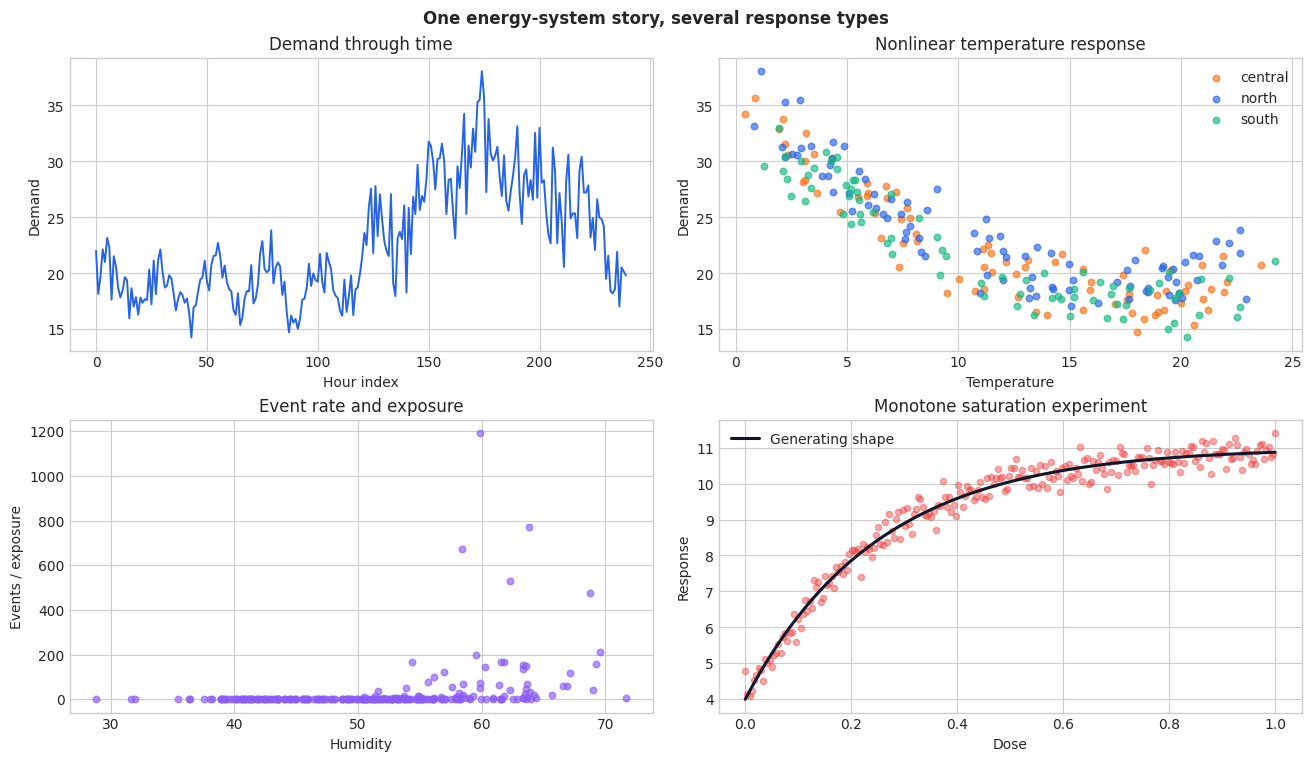

In [2]:
site_colors = {"north": COLORS[0], "central": COLORS[1], "south": COLORS[2]}
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), constrained_layout=True)

axes[0, 0].plot(data["time"], data["demand"], color=COLORS[0], linewidth=1.4)
axes[0, 0].set(title="Demand through time", xlabel="Hour index", ylabel="Demand")

for level in data["site"].cat.categories:
    subset = data["site"] == level
    axes[0, 1].scatter(
        data.loc[subset, "temperature"],
        data.loc[subset, "demand"],
        s=22,
        alpha=0.65,
        color=site_colors[str(level)],
        label=str(level),
    )
axes[0, 1].set(title="Nonlinear temperature response", xlabel="Temperature", ylabel="Demand")
axes[0, 1].legend(frameon=False)

axes[1, 0].scatter(data["humidity"], data["events"] / data["exposure"], s=22, alpha=0.65, color=COLORS[3])
axes[1, 0].set(title="Event rate and exposure", xlabel="Humidity", ylabel="Events / exposure")

axes[1, 1].scatter(data["dose"], data["shape_y"], s=20, alpha=0.45, color=COLORS[4])
axes[1, 1].plot(data["dose"], shape_mean, color="#0F172A", linewidth=2.2, label="Generating shape")
axes[1, 1].set(title="Monotone saturation experiment", xlabel="Dose", ylabel="Response")
axes[1, 1].legend(frameon=False)

fig.suptitle("One energy-system story, several response types", fontweight="bold")
plt.show()
plt.close(fig)


## 4. First model: Gaussian demand with cyclic and ordinary smooths

Demand has a nonlinear temperature response, a 24-hour cycle, and site-level
differences. A cubic regression spline estimates the temperature shape; a
cyclic cubic spline forces midnight and the end of the day to join smoothly;
the categorical site enters parametrically.

`GAMRegressor` and `GAMClassifier` provide sklearn-style methods while exposing
the fitted parity backend as `gam_`.


In [3]:
from nampy.models import GAMClassifier, GAMRegressor

model = GAMRegressor(
    formula=(
        "demand ~ s(temperature, k=10, bs='cr') "
        "+ s(hour, k=8, bs='cc') + site"
    ),
    optimize_smoothing=True,
    smoothing_method="reml",
)
model.get_params(deep=False)

model.fit(data)
predictions = model.predict(data)
r2 = model.score(data, data["demand"])
metrics = model.evaluate(data, data["demand"])
components = model.predict_components(data)
components.validate_additive_reconstruction()
explanation = model.explain_terms(data, max_bins=30)
importance = model.term_importance(data)
display(model.summary())
display(importance)
display(explanation.head(12))



Family: gaussian
Link function: identity

Formula:
demand ~ s(temperature, k=10, bs='cr') + s(hour, k=8, bs='cc') + site

Parametric coefficients:
                 Estimate   Std. Error      t value     Pr(>|t|)    
(Intercept)        22.534     0.090328       249.47       <2e-16 ***
site[north]        1.3293      0.12433       10.691       <2e-16 ***
site[south]      -0.91813      0.13085      -7.0168    2.634e-11 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                        edf       Ref.df            F      p-value    
s(temperature, k=10, bs='cr')        6.5526       7.6755       1119.3       <2e-16 ***
s(hour, k=8, bs='cc')                5.2013            6       157.61       <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.976   Deviance explained = 97.7%
-REML = 304.31  Scale est. = 0.62172  n = 240


GAMSummary(family_name='gaussian', link_name='identity', formula="demand ~ s(temperature, k=10, bs='cr') + s(hour, k=8, bs='cc') + site", p_coeff=array([22.53434611,  1.3293028 , -0.91813009]), se=array([0.09032826, 0.12433323, 0.13084758, 0.19317468, 0.15615294,
       0.18051927, 0.1758145 , 0.16261441, 0.1755368 , 0.15106531,
       0.1953019 , 0.40658691, 0.13873112, 0.13681816, 0.13853482,
       0.13992446, 0.13706636, 0.13774241]), p_t=array([249.47171401,  10.6914524 ,  -7.01679057]), p_pv=array([3.91710701e-277, 7.63361955e-022, 2.63371919e-011]), p_table=              Estimate  Std. Error     t value       Pr(>|t|)
(Intercept)  22.534346    0.090328  249.471714  3.917107e-277
site[north]   1.329303    0.124333   10.691452   7.633620e-22
site[south]  -0.918130    0.130848   -7.016791   2.633719e-11, pterms_table=  label   df   wald_stat       p_value test covariance  dispersion
0  site  2.0  161.053047  3.727986e-44    F      bayes    0.621716, s_table=                        

,term,term_type,output,importance
0,"s(temperature, k=10, bs='cr')",main,0,4.162145
1,"s(hour, k=8, bs='cc')",main,0,1.412007
2,site[north],main,0,0.770501


,term,term_type,output,value,contribution,count,importance
0,site[north],main,0,site[north],0.204321,240,0.770501
1,"s(temperature, k=10, bs='cr')",main,0,1.2705,10.438221,8,4.162145
2,"s(temperature, k=10, bs='cr')",main,0,2.295,9.060311,8,4.162145
3,"s(temperature, k=10, bs='cr')",main,0,2.797,8.120147,8,4.162145
4,"s(temperature, k=10, bs='cr')",main,0,3.374,7.392107,8,4.162145
5,"s(temperature, k=10, bs='cr')",main,0,3.999,6.154551,8,4.162145
6,"s(temperature, k=10, bs='cr')",main,0,4.7115,5.321538,8,4.162145
7,"s(temperature, k=10, bs='cr')",main,0,5.262,4.476857,8,4.162145
8,"s(temperature, k=10, bs='cr')",main,0,5.7,3.844946,8,4.162145
9,"s(temperature, k=10, bs='cr')",main,0,6.322,3.044042,8,4.162145


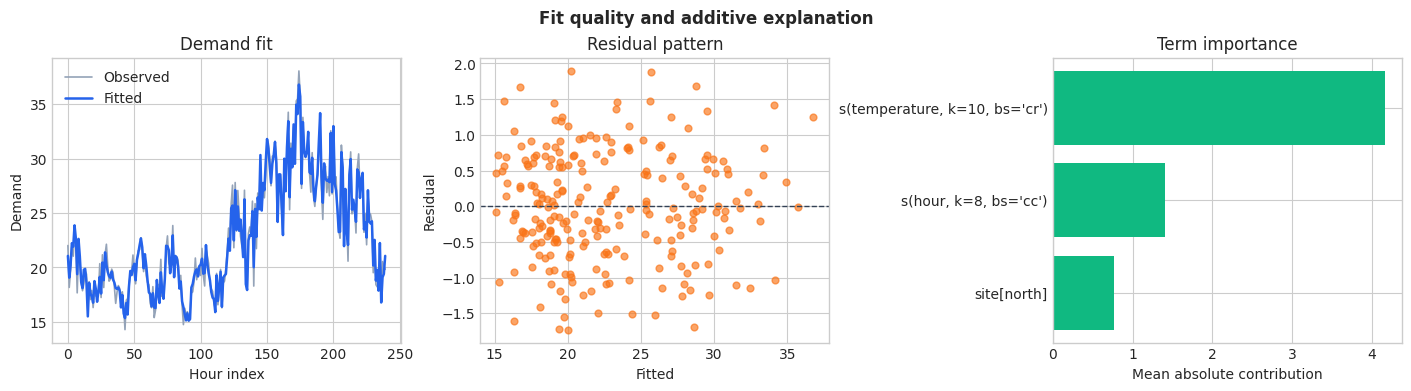

In [4]:
observed = data["demand"].to_numpy()
residual = observed - predictions
importance_plot = importance.sort_values("importance")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].plot(data["time"], observed, color="#94A3B8", linewidth=1.2, label="Observed")
axes[0].plot(data["time"], predictions, color=COLORS[0], linewidth=1.8, label="Fitted")
axes[0].set(title="Demand fit", xlabel="Hour index", ylabel="Demand")
axes[0].legend(frameon=False)

axes[1].scatter(predictions, residual, s=24, alpha=0.65, color=COLORS[1])
axes[1].axhline(0, color="#334155", linestyle="--", linewidth=1)
axes[1].set(title="Residual pattern", xlabel="Fitted", ylabel="Residual")

axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Term importance", xlabel="Mean absolute contribution")
fig.suptitle("Fit quality and additive explanation", fontweight="bold")
plt.show()
plt.close(fig)


## 5. Smooth construction gallery

Different bases encode different boundary behavior and penalty null spaces.
The choice should follow the covariate geometry rather than be treated as a
generic tuning label.

| Term | Role |
|---|---|
| `cr`, `cs` | cubic regression spline; `cs` adds null-space shrinkage |
| `cc` | cyclic cubic spline for periodic covariates |
| `ps` | P-spline with difference penalties |
| `gp` | low-rank Gaussian-process smooth with spherical, power-exponential, or Matérn covariance |
| `tp`, `ts` | thin-plate regression spline; `ts` adds shrinkage |
| `te(...)` | scale-invariant tensor product including main-effect directions |
| `ti(...)` | tensor interaction with marginal main-effect directions removed |
| `re` | random-effect/ridge-penalized factor block |
| `fs`, `sz` | factor-specific smooths with different identifiability structures |

Tensor products construct marginal bases first and combine their columns and
penalties. `te` is suitable for a whole surface; `ti` is useful when marginal
main effects are already present.


In [5]:
from nampy.gam import GAM

smooth_examples = {
    "cubic": GAM(formula="demand ~ s(temperature, bs='cr', k=10)"),
    "shrinkage_cubic": GAM(formula="demand ~ s(temperature, bs='cs', k=10)"),
    "cyclic": GAM(formula="demand ~ s(hour, bs='cc', k=8)"),
    "p_spline": GAM(formula="demand ~ s(temperature, bs='ps', k=10)"),
    "gaussian_process": GAM(
        formula="demand ~ s(temperature, humidity, bs='gp', k=20, m=[3, 1.0])"
    ),
    "thin_plate": GAM(formula="demand ~ s(temperature, bs='tp', k=10)"),
    "shrinkage_thin_plate": GAM(formula="demand ~ s(temperature, bs='ts', k=10)"),
    "tensor_surface": GAM(
        formula="demand ~ te(temperature, humidity, bs=['cr', 'ps'], k=[6, 6])"
    ),
    "tensor_interaction": GAM(
        formula=(
            "demand ~ s(temperature, bs='cr', k=8) "
            "+ s(humidity, bs='ps', k=8) "
            "+ ti(temperature, humidity, bs=['cr', 'ps'], k=[6, 6])"
        )
    ),
    "random_effect": GAM(formula="demand ~ s(site, bs='re')"),
    "factor_smooth": GAM(
        formula="demand ~ s(site, temperature, bs='fs', k=5, xt='cr')"
    ),
    "sum_to_zero_factor_smooth": GAM(
        formula="demand ~ s(site, temperature, bs='sz', k=5, xt='cr')"
    ),
}
sorted(smooth_examples)


['cubic',
 'cyclic',
 'factor_smooth',
 'gaussian_process',
 'p_spline',
 'random_effect',
 'shrinkage_cubic',
 'shrinkage_thin_plate',
 'sum_to_zero_factor_smooth',
 'tensor_interaction',
 'tensor_surface',
 'thin_plate']

## 6. Criteria and outer optimizers

The following objects demonstrate the supported public optimizer names. In
practice, compare converged endpoints and diagnostics rather than choosing the
optimizer with the smallest iteration count. `fixed` smoothing is also useful
for reproducible sensitivity analysis and constructor-level parity work.


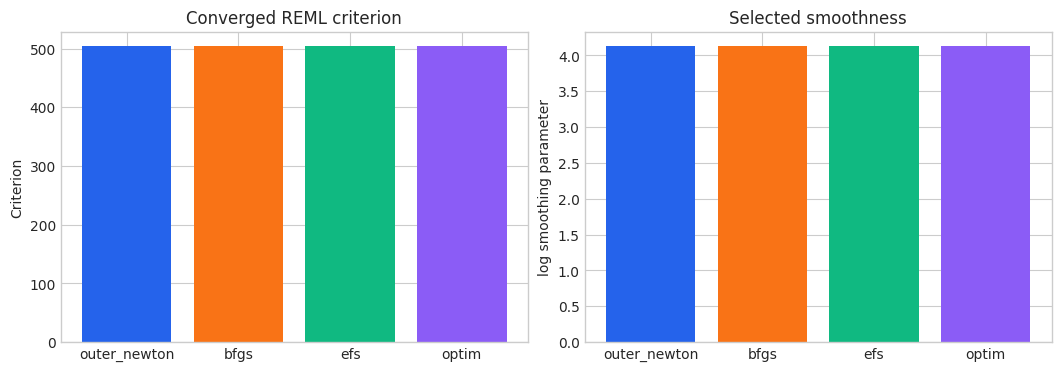

In [6]:
optimizer_models = {
    name: GAM(
        formula="demand ~ s(temperature, bs='cr', k=10)",
        family="gaussian",
        optimize_smoothing=True,
        smoothing_method="reml",
        smoothing_optimizer=name,
    )
    for name in ("outer_newton", "bfgs", "efs", "optim")
}

fixed_model = GAM(
    formula="demand ~ s(temperature, bs='cr', k=10)",
    family="gaussian",
    optimize_smoothing=False,
    smoothing_method="fixed",
    smoothing_params=[0.7],
)

fitted_optimizers = {
    name: candidate.fit(data=data) for name, candidate in optimizer_models.items()
}
optimizer_summary = pd.DataFrame(
    {
        "optimizer": name,
        "criterion": candidate.fit_result(include_covariances=False).criterion_value,
        "log_sp": np.log(candidate.fit_result(include_covariances=False).smoothing_params[0]),
    }
    for name, candidate in fitted_optimizers.items()
)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), constrained_layout=True)
axes[0].bar(optimizer_summary["optimizer"], optimizer_summary["criterion"], color=COLORS[:4])
axes[0].set(title="Converged REML criterion", ylabel="Criterion")
axes[1].bar(optimizer_summary["optimizer"], optimizer_summary["log_sp"], color=COLORS[:4])
axes[1].set(title="Selected smoothness", ylabel="log smoothing parameter")
plt.show()
plt.close(fig)


## 7. Families and links in the same application

The linear predictor always has additive structure, but the family determines
the conditional distribution and the inverse-link interpretation.

| Response | Example family/link | Interpretation |
|---|---|---|
| continuous demand | Gaussian/identity | additive changes in the mean |
| event count | Poisson/log | additive log-rate; exposure enters as an offset |
| binary alert | Binomial/logit | additive log odds |
| positive cost | Gamma/log | additive log mean with mean-dependent variance |
| overdispersed count | negative binomial/log | Poisson-like mean with extra dispersion |
| proportion | beta regression/logit | conditional mean in $(0,1)$ plus precision |
| positive mass with zeros | Tweedie/log | compound Poisson-Gamma mean |
| ordered category | ordered categorical | thresholded latent predictor |

Family choice is not merely a transformation of `y`: it determines variance,
deviance, likelihood, working weights, residuals, and sometimes additional
parameters optimized jointly with smoothness.


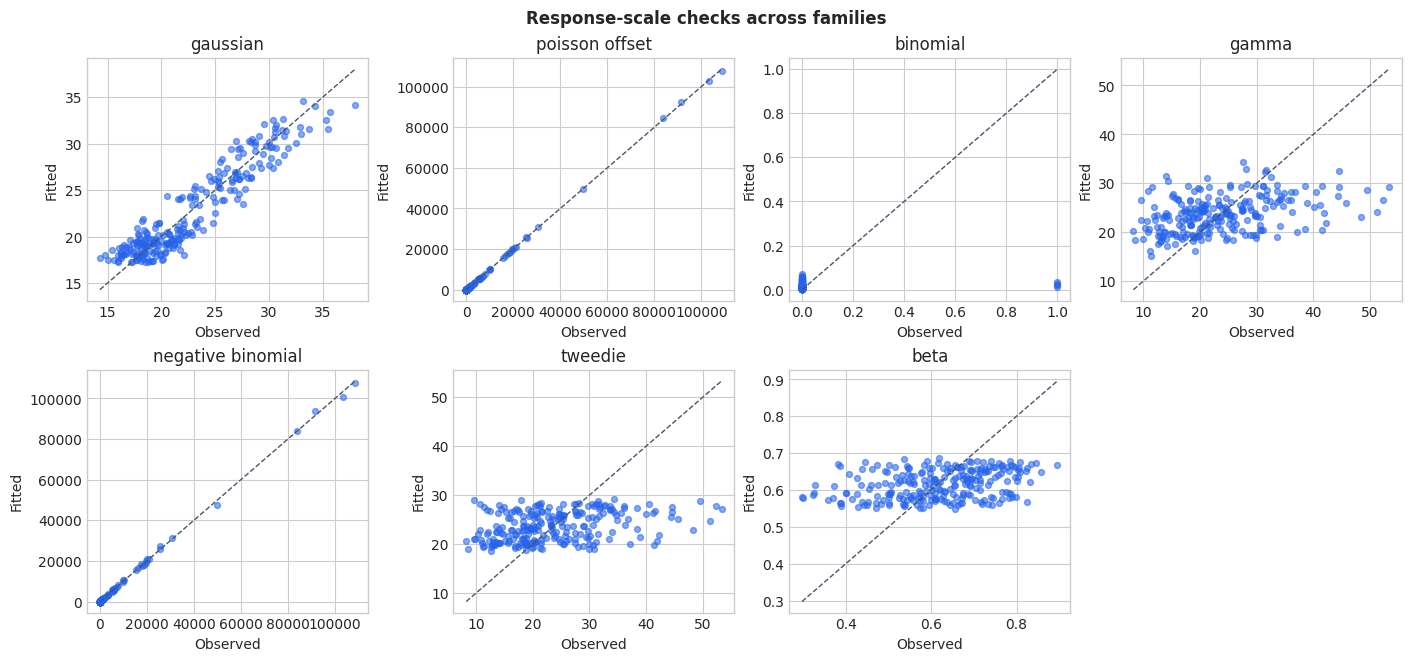

In [7]:
family_models = {
    "gaussian": GAM(
        formula="demand ~ s(temperature, bs='cr', k=10) + site",
        family="gaussian",
        optimize_smoothing=True,
        smoothing_method="reml",
    ),
    "poisson_offset": GAM(
        formula=(
            "events ~ s(temperature, bs='cr', k=9) "
            "+ s(humidity, bs='ps', k=8) + offset(log_exposure)"
        ),
        family="poisson",
        optimize_smoothing=True,
        smoothing_method="ubre",
        smoothing_optimizer="bfgs",
    ),
    "binomial": GAM(
        formula="alert ~ s(temperature, bs='cr', k=9) + site",
        family={"name": "binomial", "link": "logit"},
        optimize_smoothing=True,
        smoothing_method="reml",
    ),
    "gamma": GAM(
        formula="cost ~ s(humidity, bs='cr', k=9) + s(temperature, bs='ps', k=8)",
        family={"name": "gamma", "link": "log"},
        optimize_smoothing=True,
        smoothing_method="reml",
    ),
    "negative_binomial": GAM(
        formula="events ~ s(temperature, bs='cr', k=9) + offset(log_exposure)",
        family={"name": "nb"},
        optimize_smoothing=True,
        smoothing_method="reml",
    ),
    "tweedie": GAM(
        formula="cost ~ s(temperature, bs='cr', k=9)",
        family={"name": "tweedie", "link": "log"},
        optimize_smoothing=True,
        smoothing_method="reml",
    ),
    "beta": GAM(
        formula="efficiency ~ s(temperature, bs='cr', k=9)",
        family={"name": "betar", "link": "logit", "theta": 12.0},
        optimize_smoothing=True,
        smoothing_method="reml",
    ),
}

fitted_families = {
    name: candidate.fit(data=data) for name, candidate in family_models.items()
}
response_columns = {
    "gaussian": "demand",
    "poisson_offset": "events",
    "binomial": "alert",
    "gamma": "cost",
    "negative_binomial": "events",
    "tweedie": "cost",
    "beta": "efficiency",
}
fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), constrained_layout=True)
for ax, (name, candidate) in zip(axes.flat, fitted_families.items(), strict=False):
    observed = data[response_columns[name]].to_numpy()
    fitted = np.asarray(candidate.predict(data, type="response")).reshape(-1)
    ax.scatter(observed, fitted, s=18, alpha=0.55, color=COLORS[0])
    lo, hi = min(observed.min(), fitted.min()), max(observed.max(), fitted.max())
    ax.plot([lo, hi], [lo, hi], "--", color="#475569", linewidth=1)
    ax.set(title=name.replace("_", " "), xlabel="Observed", ylabel="Fitted")
axes.flat[-1].axis("off")
fig.suptitle("Response-scale checks across families", fontweight="bold")
plt.show()
plt.close(fig)


## 8. Multi-linear-predictor GAMs

General families can own more than one additive predictor. For Gaussian
location-scale modeling, NAMpy's `gaulss` family uses one predictor for the
conditional mean and another for the scale parameter. Each predictor has its
own formula, design matrix, smooths, penalties, and offsets, while joint
likelihood derivatives couple their estimation.

This is different from fitting two unrelated GAMs: both predictors describe
one response distribution and their covariance follows from one joint fit.


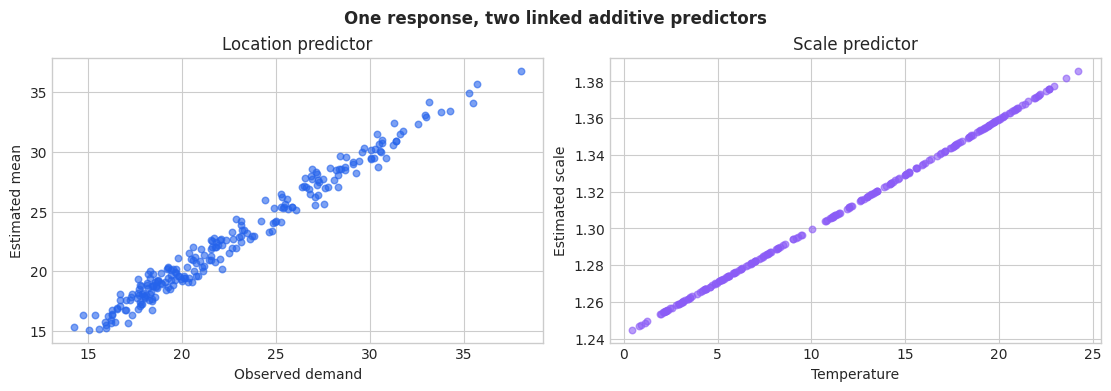

In [8]:
location_scale = GAM(
    formula=[
        "demand ~ s(temperature, bs='cr', k=9) + s(hour, bs='cc', k=8) + site",
        "~ s(temperature, bs='cr', k=7)",
    ],
    family="gaulss",
    optimize_smoothing=True,
    smoothing_method="ml",
    smoothing_optimizer="outer_newton",
)

gamma_location_scale = GAM(
    formula=[
        "cost ~ s(temperature, bs='cr', k=8) + s(humidity, bs='ps', k=8)",
        "~ 1",
    ],
    family="gammals",
    optimize_smoothing=True,
    smoothing_method="ml",
    smoothing_optimizer="outer_newton",
    select=True,
)

location_scale.fit(data=data)
mean_and_scale, mean_and_scale_se = location_scale.predict(
    data, type="response", return_se=True
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(data["demand"], mean_and_scale[:, 0], s=22, alpha=0.6, color=COLORS[0])
axes[0].set(title="Location predictor", xlabel="Observed demand", ylabel="Estimated mean")
axes[1].scatter(data["temperature"], mean_and_scale[:, 1], s=22, alpha=0.6, color=COLORS[3])
axes[1].set(title="Scale predictor", xlabel="Temperature", ylabel="Estimated scale")
fig.suptitle("One response, two linked additive predictors", fontweight="bold")
plt.show()
plt.close(fig)


## 9. Shape-constrained GAM: monotone saturation

Engineering knowledge says the response in the dose experiment should never
decrease. An unconstrained smooth can violate that assumption in sparse regions.
The `mpi` basis uses a nonlinear coefficient transform whose positive
increments enforce monotonic increase, while a P-spline penalty still controls
roughness.

Pya and Wood's construction changes the coefficient parameterization rather
than clipping predictions after fitting. Consequently, prediction,
derivatives, covariance transport, and diagnostics operate on a genuinely
shape-valid fitted function.


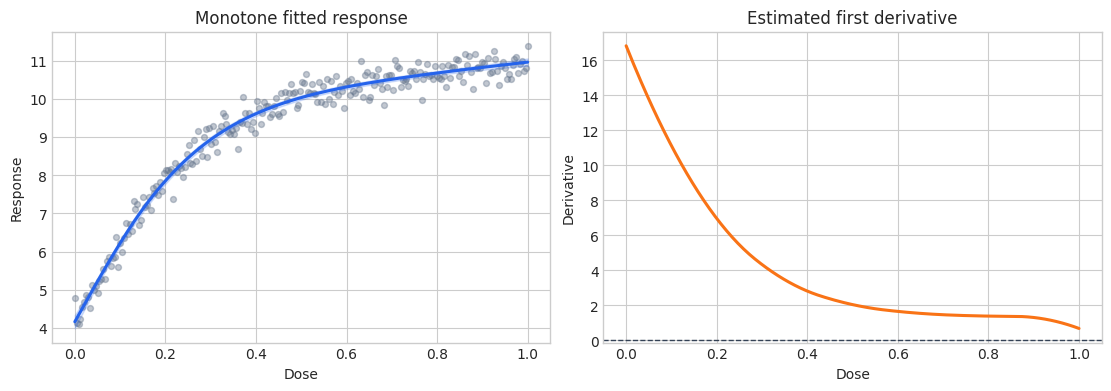

In [9]:
monotone_fixed = GAM(
    formula="shape_y ~ s(dose, bs='mpi', k=10)",
    family="gaussian",
    optimize_smoothing=False,
    smoothing_method="fixed",
    smoothing_params=[0.5],
)

monotone_selected = GAM(
    formula="shape_count ~ s(dose, bs='mpi', k=10)",
    family="poisson",
    optimize_smoothing=True,
    smoothing_method="ubre",
    smoothing_optimizer="bfgs",
)

monotone_fixed.fit(data=data)
shape_derivative = monotone_fixed.derivative(smooth_number=1, deriv=1)
assert np.min(shape_derivative.derivative) >= -1e-7
shape_fit, shape_se = monotone_fixed.predict(data, type="response", return_se=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(data["dose"], data["shape_y"], s=18, alpha=0.4, color="#64748B")
axes[0].plot(data["dose"], shape_fit, color=COLORS[0], linewidth=2.2)
axes[0].fill_between(data["dose"], shape_fit - 2 * shape_se, shape_fit + 2 * shape_se, color=COLORS[0], alpha=0.18)
axes[0].set(title="Monotone fitted response", xlabel="Dose", ylabel="Response")
axes[1].plot(data["dose"], shape_derivative.derivative, color=COLORS[1], linewidth=2.2)
axes[1].axhline(0, color="#334155", linestyle="--", linewidth=1)
axes[1].set(title="Estimated first derivative", xlabel="Dose", ylabel="Derivative")
plt.show()
plt.close(fig)


## 10. Prediction, inference, and diagnostics

Use `standard_errors`, `lpmatrix`, `summary`, and `plot` for statistical
inference and smooth inspection. The raw `GAM` surface additionally exposes
prediction types, residuals, derivatives, ANOVA, `k_check`, `gam_check`,
concurvity, covariance choices, and parity snapshots.



Family: gaussian
Link function: identity

Formula:
demand ~ s(temperature, k=10, bs='cr') + s(hour, k=8, bs='cc') + site

Parametric coefficients:
                 Estimate   Std. Error      t value     Pr(>|t|)    
(Intercept)        22.534     0.090328       249.47       <2e-16 ***
site[north]        1.3293      0.12433       10.691       <2e-16 ***
site[south]      -0.91813      0.13085      -7.0168    2.634e-11 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                        edf       Ref.df            F      p-value    
s(temperature, k=10, bs='cr')        6.5526       7.6755       1119.3       <2e-16 ***
s(hour, k=8, bs='cc')                5.2013            6       157.61       <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.976   Deviance explained = 97.7%
-REML = 304.31  Scale est. = 0.62172  n = 240


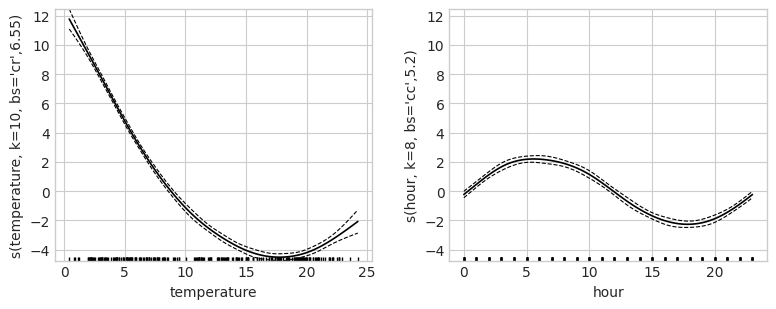

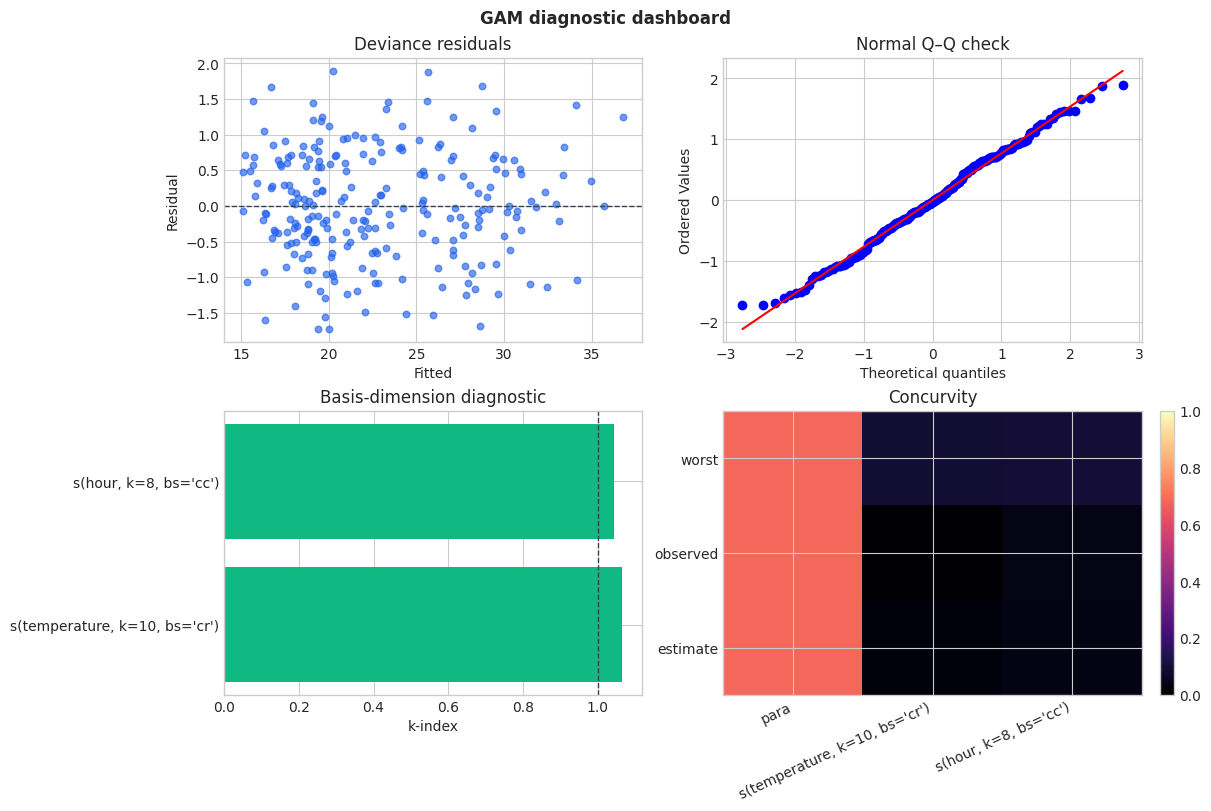

In [10]:
se = model.standard_errors(data)
Xp = model.lpmatrix(data)
terms = model.gam_.predict(data, type="terms")
response_with_se = model.gam_.predict(data, type="response", return_se=True)
residuals = model.gam_.residuals(type="deviance")
derivative_model = GAM(
    formula="demand ~ s(temperature, bs='ps', k=10)",
    family="gaussian",
    optimize_smoothing=False,
    smoothing_method="fixed",
    smoothing_params=[0.7],
).fit(data=data)
derivative = derivative_model.derivative(data, smooth_number=1, deriv=1)
summary = model.gam_.summary()
k_diagnostics = model.gam_.k_check()
check_report = model.gam_.gam_check()
concurvity = model.gam_.concurvity()
covariance = model.gam_.vcov(freq=False, unconditional=True)
snapshot = model.gam_.parity_snapshot(data)
plots = model.plot(pages=1, se=True)

from scipy import stats

fitted = np.asarray(predictions).reshape(-1)
deviance_residuals = np.asarray(residuals).reshape(-1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes[0, 0].scatter(fitted, deviance_residuals, s=22, alpha=0.65, color=COLORS[0])
axes[0, 0].axhline(0, color="#334155", linestyle="--", linewidth=1)
axes[0, 0].set(title="Deviance residuals", xlabel="Fitted", ylabel="Residual")

stats.probplot(deviance_residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Normal Q–Q check")

k_values = k_diagnostics["k_index"].to_numpy(dtype=float)
axes[1, 0].barh(k_diagnostics.index.astype(str), k_values, color=COLORS[2])
axes[1, 0].axvline(1, color="#334155", linestyle="--", linewidth=1)
axes[1, 0].set(title="Basis-dimension diagnostic", xlabel="k-index")

concurvity_values = np.asarray(concurvity["values"], dtype=float)
image = axes[1, 1].imshow(concurvity_values, vmin=0, vmax=1, cmap="magma", aspect="auto")
axes[1, 1].set_xticks(range(len(concurvity["labels"])), concurvity["labels"], rotation=25, ha="right")
axes[1, 1].set_yticks(range(len(concurvity["measure_names"])), concurvity["measure_names"])
axes[1, 1].set_title("Concurvity")
fig.colorbar(image, ax=axes[1, 1], fraction=0.046, pad=0.04)
fig.suptitle("GAM diagnostic dashboard", fontweight="bold")
plt.show()
plt.close(fig)


## 11. Direct backend, adapters, and classification

Use `nampy.gam.GAM` when you need the raw mgcv-shaped interface. The adapters
are preferable for sklearn workflows. `GAMClassifier` supports binary targets
and adds `predict_proba` and `decision_function`.


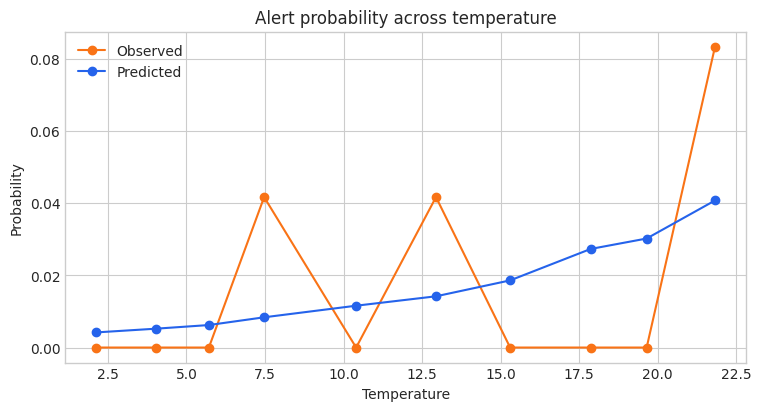

In [11]:
raw = GAM(
    formula="demand ~ s(temperature, k=10, bs='cr') + site",
    family="gaussian",
    optimize_smoothing=True,
    smoothing_method="reml",
)

classifier = GAMClassifier(
    formula="alert ~ s(temperature, k=9, bs='cr') + site",
    basis="cr",
    smoothing_method="reml",
)
raw.fit(data=data)
link = raw.predict(data, type="link")
raw_terms = raw.predict(data, type="terms", return_se=True)
classifier.fit(data, data["alert"])
probabilities = classifier.predict_proba(data)
labels = classifier.predict(data)
probability_frame = pd.DataFrame(
    {"temperature": data["temperature"], "alert": data["alert"], "probability": probabilities[:, 1]}
)
probability_frame["temperature_bin"] = pd.qcut(
    probability_frame["temperature"], q=10, duplicates="drop"
)
calibration = probability_frame.groupby("temperature_bin", observed=True).agg(
    temperature=("temperature", "mean"),
    observed_rate=("alert", "mean"),
    predicted_rate=("probability", "mean"),
)
fig, ax = plt.subplots(figsize=(7.5, 4), constrained_layout=True)
ax.plot(calibration["temperature"], calibration["observed_rate"], "o-", color=COLORS[1], label="Observed")
ax.plot(calibration["temperature"], calibration["predicted_rate"], "o-", color=COLORS[0], label="Predicted")
ax.set(title="Alert probability across temperature", xlabel="Temperature", ylabel="Probability")
ax.legend(frameon=False)
plt.show()
plt.close(fig)
